In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

data = np.load('brain_data_timeseries.npy')
true_events = np.load('true_events.npy')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    if np.isnan(f['acf_lag1']):
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

In [3]:
def func(window, step):
    timestamps = []
    scores_mahal = []
    all_features = []

    for t in range(window, len(data) - window, step):

        left_window = data[t-window:t]
        right_window = data[t:t+window]

        left_feat, feature_names = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        all_features.append(left_feat)
        all_features.append(right_feat)

    all_features = np.array(all_features)

    # covariance for Mahalanobis
    cov = np.cov(all_features.T)

    # regularization
    cov += np.eye(cov.shape[0]) * 1e-6

    cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


    # actual scoring loop
    for t in range(window, len(data) - window, step):

        left_window = data[t-window:t]
        right_window = data[t:t+window]

        left_feat, _ = extract_features(left_window)
        right_feat, _ = extract_features(right_window)

        s_mahal = mahalanobis_distance(
            left_feat,
            right_feat,
            cov_inv
        )

        timestamps.append(t)
        scores_mahal.append(s_mahal)

    timestamps = np.array(timestamps)
    scores_mahal = np.array(scores_mahal)

    return timestamps, scores_mahal

In [4]:
change_indices = (true_events * 1000).astype(int)

In [35]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Integer
from scipy.linalg import pinv

def objective(params):
    window, step = int(params[0]), int(params[1])
    timestamps, scores = func(window, step)

    half_window = 100

    hits = 0

    for change_idx in change_indices:
        nearest_idx = np.argmin(np.abs(timestamps - change_idx))
        change_time = timestamps[nearest_idx]

        inner_mask = (timestamps >= change_time - half_window) & (timestamps <= change_time + half_window)
        outer_mask = (timestamps >= change_time + half_window) & (timestamps <= change_time + half_window)

        if np.mean(scores[inner_mask]) * 0.75 > np.mean(scores[outer_mask]):
            hits += 1

    return -hits / len(change_indices)

In [36]:
space = [Integer(10, 1000), Integer(10, 50)]
result = gp_minimize(objective, space, n_calls=50, n_initial_points=10, random_state=42, verbose=True)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 60.5959
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 29.2587
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 66.9974
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 40.8293
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 25.8597
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 6 started. Evalu

In [37]:
optimal_window = int(result.x[0])
optimal_step = int(result.x[1])
print(f"\n=== OPTIMAL ===")
print(f"window={optimal_window}, step={optimal_step}, score={-result.fun:.4f}")


=== OPTIMAL ===
window=31, step=50, score=0.4146


In [39]:
result

          fun: -0.4146039603960396
            x: [np.int64(31), np.int64(50)]
    func_vals: [ 0.000e+00  0.000e+00 ... -2.698e-01  0.000e+00]
      x_iters: [[np.int64(799), np.int64(17)], [np.int64(782), np.int64(34)], [np.int64(451), np.int64(14)], [np.int64(465), np.int64(23)], [np.int64(151), np.int64(36)], [np.int64(66), np.int64(39)], [np.int64(939), np.int64(10)], [np.int64(992), np.int64(35)], [np.int64(616), np.int64(10)], [np.int64(33), np.int64(31)], [np.int64(1000), np.int64(50)], [np.int64(16), np.int64(47)], [np.int64(11), np.int64(11)], [np.int64(694), np.int64(10)], [np.int64(333), np.int64(10)], [np.int64(10), np.int64(10)], [np.int64(719), np.int64(40)], [np.int64(376), np.int64(33)], [np.int64(103), np.int64(19)], [np.int64(972), np.int64(25)], [np.int64(988), np.int64(38)], [np.int64(512), np.int64(13)], [np.int64(44), np.int64(16)], [np.int64(706), np.int64(35)], [np.int64(846), np.int64(39)], [np.int64(253), np.int64(44)], [np.int64(835), np.int64(11)], [np.int6

In [40]:
timestamps, scores = func(optimal_window, optimal_step)

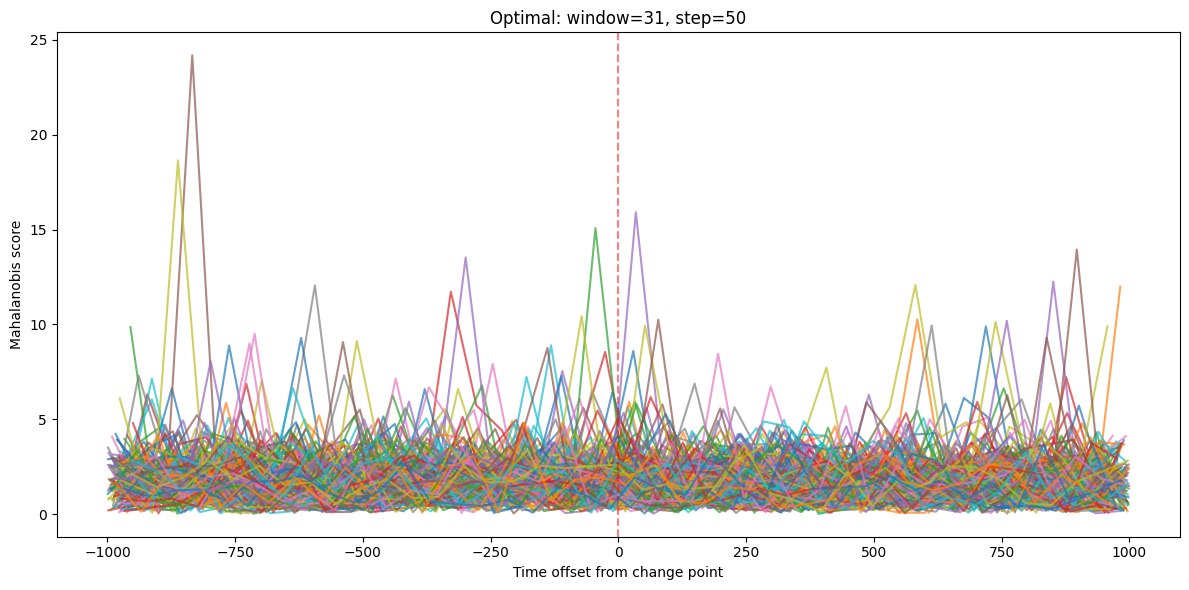

In [41]:
plt.figure(figsize=(12, 6))
for i in range(len(change_indices)//4):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    plt.plot(timestamps[mask] - change_indices[i], scores[mask], alpha=0.7)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.title(f'Optimal: window={optimal_window}, step={optimal_step}')
plt.tight_layout()
plt.show()

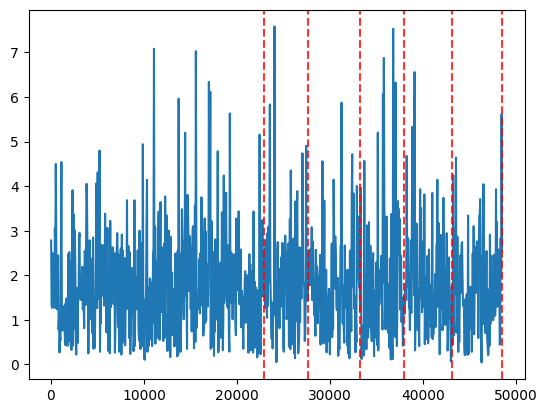

In [44]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

## old result

In [16]:
optimal_window = int(result.x[0])
optimal_step = int(result.x[1])
print(f"\n=== OPTIMAL ===")
print(f"window={optimal_window}, step={optimal_step}, score={-result.fun:.4f}")


=== OPTIMAL ===
window=782, step=34, score=0.3094


In [21]:
result

          fun: -0.3094059405940594
            x: [np.int64(782), np.int64(34)]
    func_vals: [-3.057e-01 -3.094e-01 ...  0.000e+00  0.000e+00]
      x_iters: [[np.int64(799), np.int64(17)], [np.int64(782), np.int64(34)], [np.int64(451), np.int64(14)], [np.int64(465), np.int64(23)], [np.int64(151), np.int64(36)], [np.int64(66), np.int64(39)], [np.int64(939), np.int64(10)], [np.int64(992), np.int64(35)], [np.int64(616), np.int64(10)], [np.int64(33), np.int64(31)], [np.int64(742), np.int64(12)], [np.int64(36), np.int64(34)], [np.int64(790), np.int64(45)], [np.int64(801), np.int64(11)], [np.int64(755), np.int64(34)], [np.int64(835), np.int64(48)], [np.int64(789), np.int64(22)], [np.int64(784), np.int64(34)], [np.int64(801), np.int64(17)], [np.int64(789), np.int64(17)], [np.int64(775), np.int64(33)], [np.int64(771), np.int64(34)], [np.int64(795), np.int64(34)], [np.int64(813), np.int64(17)], [np.int64(783), np.int64(35)], [np.int64(797), np.int64(18)], [np.int64(800), np.int64(16)], [np.i

In [17]:
timestamps, scores = func(optimal_window, optimal_step)

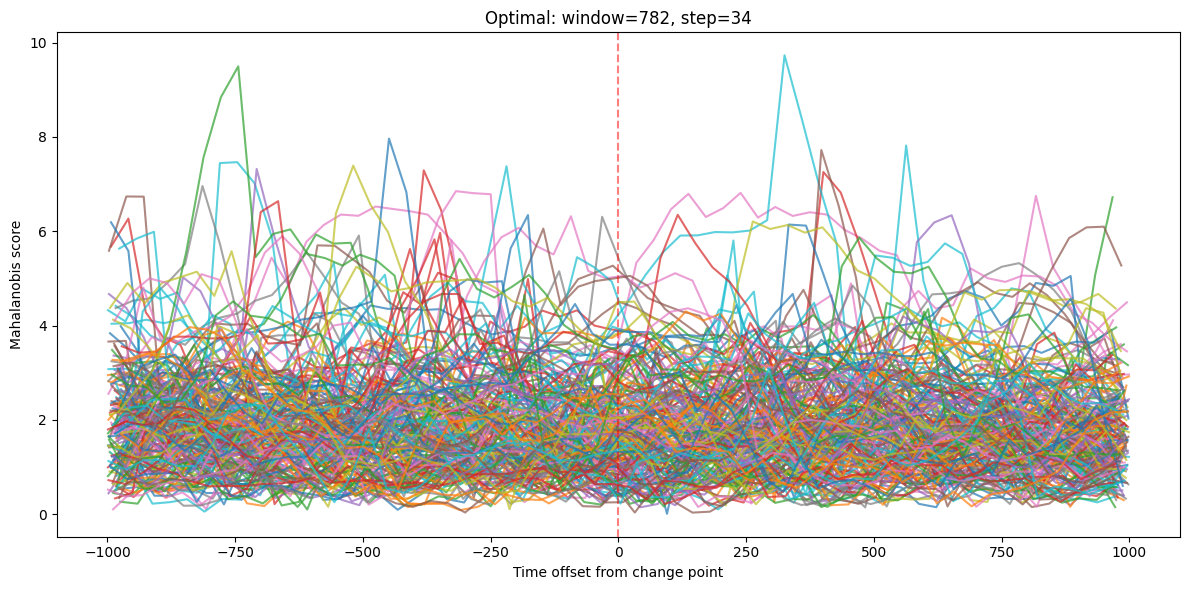

In [18]:
plt.figure(figsize=(12, 6))
for i in range(len(change_indices)//4):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    plt.plot(timestamps[mask] - change_indices[i], scores[mask], alpha=0.7)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.title(f'Optimal: window={optimal_window}, step={optimal_step}')
plt.tight_layout()
plt.show()

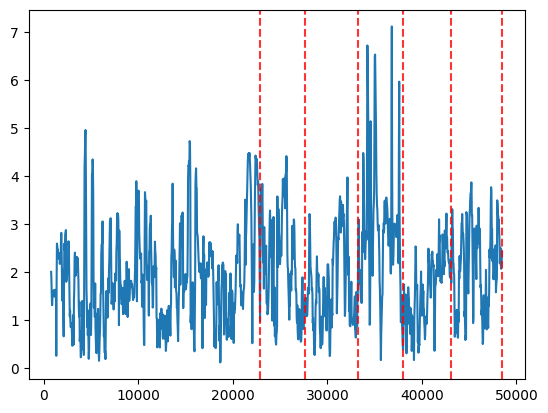

In [19]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

In [23]:
space = [Integer(50, 1000), Integer(10, 20)]
result = gp_minimize(objective, space, n_calls=30, n_initial_points=10, random_state=42, verbose=True)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 82.9767
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 61.5173
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 84.2423
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 72.4975
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 53.7969
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 6 started. Evalu

In [24]:
optimal_window = int(result.x[0])
optimal_step = int(result.x[1])
print(f"\n=== OPTIMAL ===")
print(f"window={optimal_window}, step={optimal_step}, score={-result.fun:.4f}")


=== OPTIMAL ===
window=1000, step=20, score=0.3119


In [25]:
timestamps, scores = func(1000, 20)

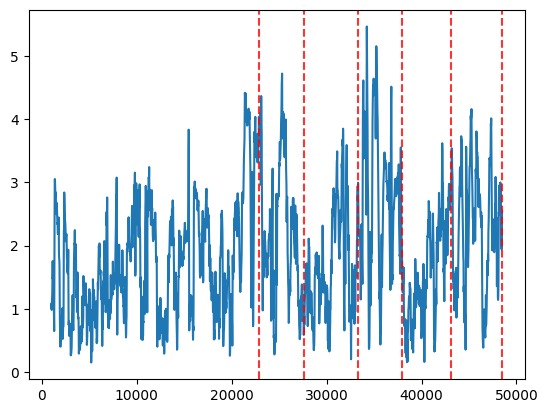

In [26]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

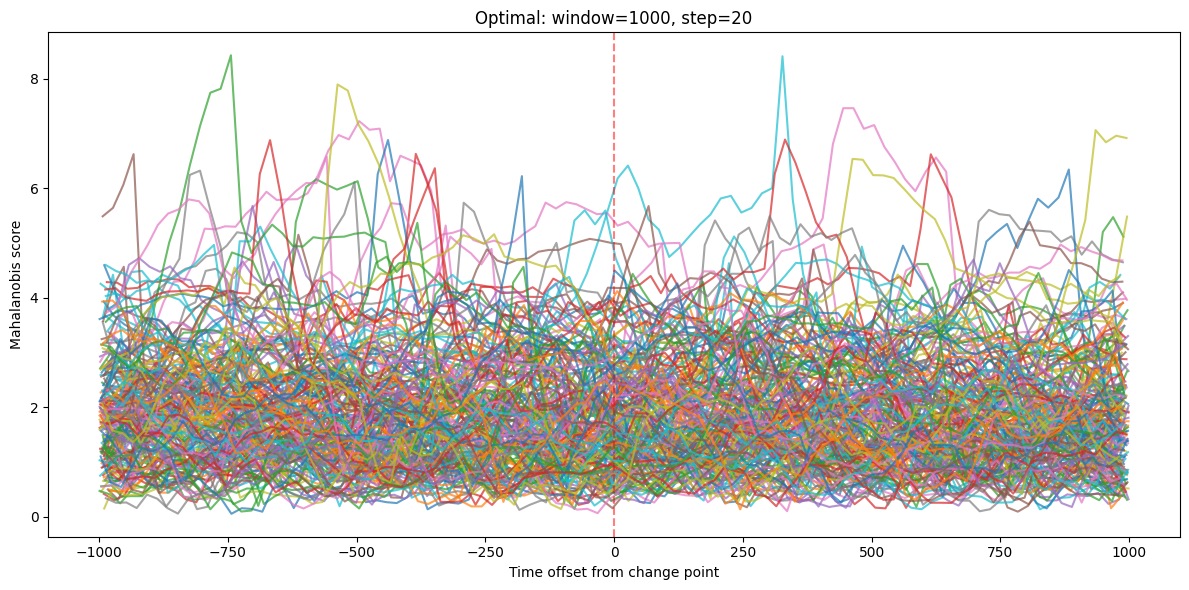

In [27]:
plt.figure(figsize=(12, 6))
for i in range(len(change_indices)//4):
    mask = (timestamps > change_indices[i] - 1000) & (timestamps < change_indices[i] + 1000)
    plt.plot(timestamps[mask] - change_indices[i], scores[mask], alpha=0.7)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Time offset from change point')
plt.ylabel('Mahalanobis score')
plt.title(f'Optimal: window={optimal_window}, step={optimal_step}')
plt.tight_layout()
plt.show()

# try out large windows w=10000

In [45]:
timestamps, scores = func(10000, 10)

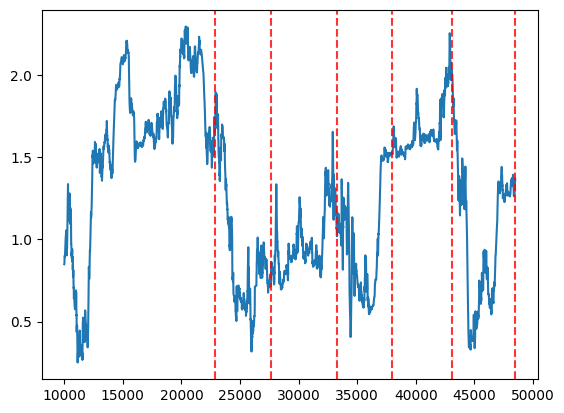

In [46]:
plt.plot(
    timestamps[timestamps < change_indices[5]],
    scores[timestamps < change_indices[5]],
)

# Plot vertical lines for change points
for cp in change_indices[:6]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

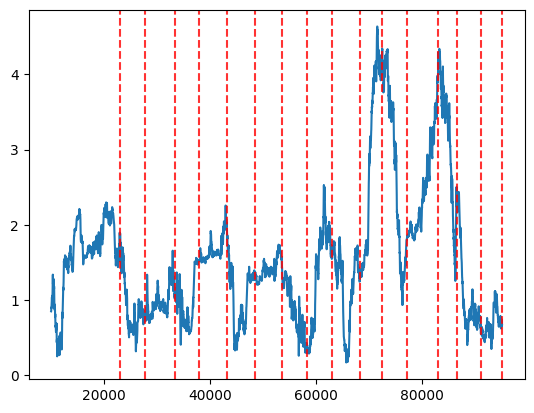

In [47]:
plt.plot(
    timestamps[timestamps < change_indices[15]],
    scores[timestamps < change_indices[15]],
)

# Plot vertical lines for change points
for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# w=100000

In [50]:
len(data)

2543000

In [48]:
timestamps, scores = func(100000, 10)

In [51]:
scores

array([0.982305  , 0.98283259, 0.98353886, ..., 7.9382261 , 7.93662922,
       7.93576968], shape=(234300,))

In [52]:
timestamps

array([ 100000,  100010,  100020, ..., 2442970, 2442980, 2442990],
      shape=(234300,))

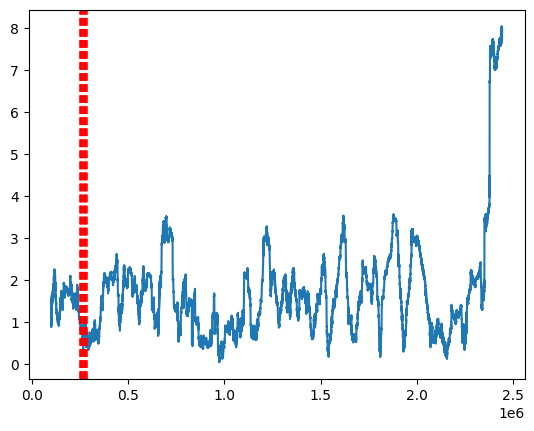

In [63]:
plt.plot(timestamps, scores)
# Plot vertical lines for change points
for cp in change_indices[50:60]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

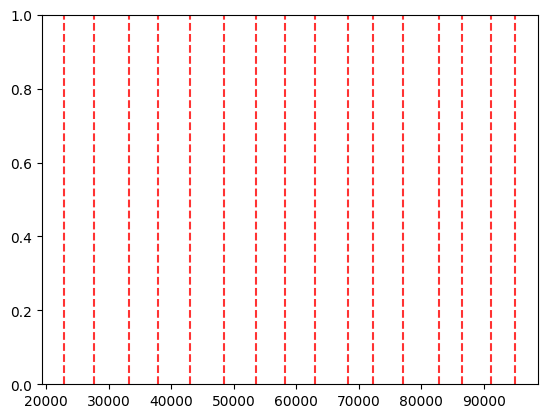

In [55]:
for cp in change_indices[:16]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

In [59]:
change_indices[15]

np.int64(95036)

In [60]:
timestamps < change_indices[15]

array([False, False, False, ..., False, False, False], shape=(234300,))

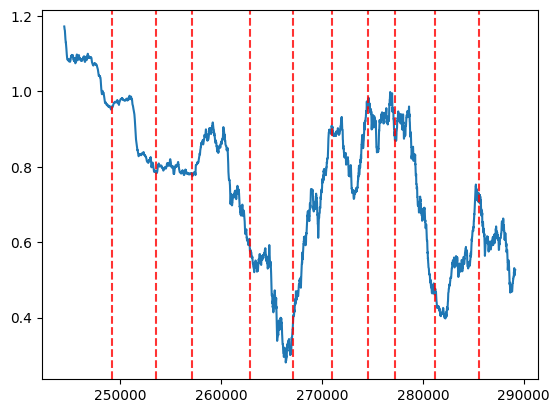

In [64]:
plt.plot(
    timestamps[(timestamps < change_indices[60]) & (timestamps > change_indices[49])],
    scores[(timestamps < change_indices[60]) & (timestamps > change_indices[49])],
)

# Plot vertical lines for change points
for cp in change_indices[50:60]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

# bayesopt for large windows

In [ ]:
space = [Integer(10000, 100000), Integer(10, 50)]
result = gp_minimize(objective, space, n_calls=50, n_initial_points=10, random_state=42, verbose=True)

In [ ]:
optimal_window = int(result.x[0])
optimal_step = int(result.x[1])
print(f"\n=== OPTIMAL ===")
print(f"window={optimal_window}, step={optimal_step}, score={-result.fun:.4f}")